In [9]:

# =============================================================================
# CELL 1 — GLOBAL CONFIGURATION
# =============================================================================
from pathlib import Path
import os
import re
import json
import itertools
import traceback
import warnings
import subprocess
import sys
from datetime import datetime

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1) Path to the final Pairwise notebook
# -----------------------------------------------------------------------------
# Put this batch notebook next to Pairwise.ipynb, or set the full path here.
PAIRWISE_NOTEBOOK_PATH = Path("Pairwise.ipynb")
AUTO_FIND_PAIRWISE_NOTEBOOK = True

# -----------------------------------------------------------------------------
# 2) Input base datasets
# -----------------------------------------------------------------------------
# Recommended: explicitly list your 5 base datasets here.
# Example:
# RAW_DATASET_FILES = [
#     "output/single_datasets_report_only/Pre_M1.csv",
#     "output/single_datasets_report_only/Post1_M1.csv",
#     "output/single_datasets_report_only/Post2_M1.csv",
#     "output/single_datasets_report_only/ADC_M1.csv",
#     "output/single_datasets_report_only/T2_M1.csv",
# ]
RAW_DATASET_FILES = [
    # EDIT THESE 5 PATHS:
    # "output/single_datasets_report_only/Pre_M1.csv",
    # "output/single_datasets_report_only/Post1_M1.csv",
    # "output/single_datasets_report_only/Post2_M1.csv",
    # "output/single_datasets_report_only/ADC_M1.csv",
    # "output/single_datasets_report_only/T2_M1.csv",
]

# If RAW_DATASET_FILES is empty, auto-discover CSVs from this folder.
AUTO_DISCOVER_DATASETS = True
SOURCE_DATASET_DIR = Path("../Dataset/Breast-Data/Mask1")
DATASET_GLOB_PATTERN = "*.csv"

# With 5 datasets this creates 10 pairs. Set the flag False for any other count.
REQUIRE_EXACTLY_FIVE_DATASETS = True

# -----------------------------------------------------------------------------
# 3) Column names and alignment policy
# -----------------------------------------------------------------------------
LABEL_COL = "Label"
GROUP_COL = "PatientID"

# Candidate columns used to align two modalities/phases.
# INFO_NameOfRoi is usually the safest key for your lesion-level radiomics files.
ROI_CANDIDATE_COLUMNS = [
    "INFO_NameOfRoi",
    "NameOfRoi",
    "ROI",
    "ROI_Name",
    "LesionID",
    "Lesion_ID",
]

# Merge key priority. The code keeps the first one that exists and is unique in both datasets.
MERGE_KEY_PRIORITY = [
    ["INFO_NameOfRoi"],
    ["PatientID", "INFO_NameOfRoi"],
    ["LesionID"],
    ["Lesion_ID"],
    ["ROI_Name"],
]

# If no unique key exists but both datasets have exactly the same row order,
# this fallback uses row index only after checking the PatientID sequence matches.
ALLOW_ROW_ORDER_FALLBACK = True
MERGE_HOW = "inner"

# -----------------------------------------------------------------------------
# 4) Output locations
# -----------------------------------------------------------------------------
PAIRWISE_DATASET_DIR = Path("output/all_10_pairwise_concat_datasets")
BATCH_ROOT = Path("nested_cv_outputs_all_pairwise_concat_batch_smote_compare")
BATCH_RUN_ROOT = Path("batch_all_10_pairwise_runner_artifacts_smote_compare")

EXECUTED_NOTEBOOK_DIR = BATCH_RUN_ROOT / "executed_pairwise_notebooks"
MISMATCH_REPORT_DIR = BATCH_RUN_ROOT / "label_mismatch_reports"
SUMMARY_DIR = BATCH_RUN_ROOT / "summary_tables"

for p in [PAIRWISE_DATASET_DIR, BATCH_ROOT, BATCH_RUN_ROOT, EXECUTED_NOTEBOOK_DIR, MISMATCH_REPORT_DIR, SUMMARY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# 5) Notebook execution options
# -----------------------------------------------------------------------------
EXECUTE_PAIRWISE_NOTEBOOKS = True
SKIP_EXISTING_SUCCESSFUL_RUNS = False
OVERWRITE_FS_RUNS = True
COMPARE_SMOTE_OPTIONS = True
RUN_SMOTE_ABLATION = False
RUN_SMOTE_VS_BASELINE_COMPARISON = False
KERNEL_NAME = "python3"
NOTEBOOK_TIMEOUT_SECONDS = None  # None = no timeout

# This modifies only metadata of Pairwise.ipynb once so papermill knows where to inject parameters.
# It does not create per-pair copies of Pairwise.ipynb.
ADD_PARAMETERS_TAG_TO_PAIRWISE = True

# Optional small in-place patch: make the final zip path pair-specific instead of overwriting one zip.
# It still uses the same Pairwise.ipynb; no per-pair copies are created.
PATCH_FINAL_ZIP_OUTPUT_IN_PLACE = True

print("Configuration loaded.")
print(f"PAIRWISE_DATASET_DIR: {PAIRWISE_DATASET_DIR.resolve()}")
print(f"BATCH_ROOT:           {BATCH_ROOT.resolve()}")
print(f"SUMMARY_DIR:          {SUMMARY_DIR.resolve()}")


Configuration loaded.
PAIRWISE_DATASET_DIR: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Pairwise/output/all_10_pairwise_concat_datasets
BATCH_ROOT:           /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Pairwise/nested_cv_outputs_all_pairwise_concat_batch_smote_compare
SUMMARY_DIR:          /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Pairwise/batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables


In [10]:

# =============================================================================
# CELL 2 — ONE-TIME DEPENDENCY CHECK
# =============================================================================
# papermill is used only to pass parameters directly into the same Pairwise.ipynb.

def ensure_import(import_name, pip_name=None):
    import importlib.util
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"OK: {import_name}")

ensure_import("nbformat", "nbformat")
ensure_import("papermill", "papermill")
ensure_import("statsmodels", "statsmodels")
ensure_import("imblearn", "imbalanced-learn")

import nbformat
import papermill as pm

print("Dependency check completed.")


OK: nbformat
OK: papermill
OK: statsmodels
OK: imblearn
Dependency check completed.


In [11]:

# =============================================================================
# CELL 3 — FILE DISCOVERY AND VALIDATION
# =============================================================================

def find_pairwise_notebook(path: Path) -> Path:
    if path.exists():
        return path.resolve()

    if not AUTO_FIND_PAIRWISE_NOTEBOOK:
        raise FileNotFoundError(f"Pairwise notebook not found: {path}")

    candidates = []
    for root in [Path.cwd(), Path("/kaggle/input"), Path("/mnt/data")]:
        if root.exists():
            try:
                candidates.extend(root.rglob(PAIRWISE_NOTEBOOK_PATH.name))
            except Exception:
                pass

    candidates = sorted(set(candidates))
    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Could not find {PAIRWISE_NOTEBOOK_PATH.name}. Put it next to this notebook or set PAIRWISE_NOTEBOOK_PATH."
        )

    print(f"Found {PAIRWISE_NOTEBOOK_PATH.name} candidates:")
    for c in candidates:
        print("  -", c)

    return candidates[0].resolve()


def discover_dataset_files():
    if len(RAW_DATASET_FILES) > 0:
        files = [Path(x) for x in RAW_DATASET_FILES]
    else:
        if not AUTO_DISCOVER_DATASETS:
            raise ValueError("RAW_DATASET_FILES is empty and AUTO_DISCOVER_DATASETS=False.")
        if not SOURCE_DATASET_DIR.exists():
            raise FileNotFoundError(
                f"SOURCE_DATASET_DIR does not exist: {SOURCE_DATASET_DIR}\n"
                "Either create this folder or fill RAW_DATASET_FILES manually."
            )
        files = sorted(SOURCE_DATASET_DIR.glob(DATASET_GLOB_PATTERN))

    # Avoid accidentally picking already-created pairwise or summary CSVs.
    filtered = []
    for p in files:
        stem_lower = p.stem.lower()
        if any(x in stem_lower for x in ["pairwise", "summary", "comparison", "random_label"]):
            continue
        filtered.append(p)

    files = [p.resolve() for p in filtered]

    missing = [str(p) for p in files if not p.exists()]
    if missing:
        raise FileNotFoundError("These dataset files were not found:\n" + "\n".join(missing))

    if REQUIRE_EXACTLY_FIVE_DATASETS and len(files) != 5:
        raise ValueError(
            f"Expected exactly 5 base datasets to create 10 pairs, but found {len(files)}.\n"
            "Files found:\n" + "\n".join(str(p) for p in files) + "\n\n"
            "Fix RAW_DATASET_FILES or SOURCE_DATASET_DIR."
        )

    return files


PAIRWISE_NOTEBOOK_PATH = find_pairwise_notebook(PAIRWISE_NOTEBOOK_PATH)
DATASET_FILES = discover_dataset_files()

print("Pairwise notebook:")
print(" ", PAIRWISE_NOTEBOOK_PATH)

print("\nBase datasets:")
for i, f in enumerate(DATASET_FILES, start=1):
    print(f"{i}. {f}")

expected_pairs = len(DATASET_FILES) * (len(DATASET_FILES) - 1) // 2
print(f"\nNumber of concat pairs to create: {expected_pairs}")


Pairwise notebook:
  /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Pairwise/Pairwise.ipynb

Base datasets:
1. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/ADC_M1.csv
2. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post1_M1.csv
3. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post2_M1.csv
4. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Pre_M1.csv
5. /Users/mahla

In [12]:

# =============================================================================
# CELL 4 — DATASET READING, TAGGING, AND PAIRWISE CONCAT FUNCTIONS
# =============================================================================

def clean_tag_from_path(path):
    """Create a compact dataset tag from filename."""
    stem = Path(path).stem
    suffixes = ["_Cleaned", "_cleaned", "_M1_pairwise", "_pairwise", "_M1"]
    changed = True
    while changed:
        changed = False
        for s in suffixes:
            if stem.endswith(s):
                stem = stem[: -len(s)]
                changed = True
    stem = re.sub(r"[^A-Za-z0-9]+", "_", stem).strip("_")
    return stem


def read_csv_flexible(path):
    """Read comma-, semicolon-, tab-, or whitespace-separated CSV robustly."""
    path = Path(path)
    attempts = [
        dict(sep=None, engine="python"),
        dict(sep=","),
        dict(sep=";"),
        dict(sep="\t"),
        dict(sep=r"\s+", engine="python"),
    ]
    last_error = None
    for kwargs in attempts:
        try:
            df = pd.read_csv(path, **kwargs)
            if df.shape[1] > 1:
                return df
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not read CSV correctly: {path}\nLast error: {last_error}")


def normalize_column_lookup(df):
    return {str(c).strip().lower(): c for c in df.columns}


def resolve_column(df, preferred, candidates=None, required=True, role_name="column"):
    candidates = candidates or []
    lookup = normalize_column_lookup(df)
    for term in [preferred] + list(candidates):
        if term is None:
            continue
        key = str(term).strip().lower()
        if key in lookup:
            return lookup[key]
    if required:
        raise ValueError(
            f"Could not find required {role_name}. Preferred={preferred}, candidates={candidates}. "
            f"Available columns include: {list(df.columns[:20])}"
        )
    return None


def standardize_label_column(df):
    df = df.copy()
    detected_label = resolve_column(
        df,
        LABEL_COL,
        candidates=["label", "Label", "Class", "class", "target", "Target", "diagnosis"],
        required=True,
        role_name="label column",
    )
    if detected_label != LABEL_COL:
        df = df.rename(columns={detected_label: LABEL_COL})
    return df


def find_first_existing_column(df, candidates):
    lookup = normalize_column_lookup(df)
    for c in candidates:
        key = str(c).strip().lower()
        if key in lookup:
            return lookup[key]
    return None


def derive_patient_id(df):
    """Create/normalize PatientID. For your files, ROI names such as M1_S2_P1_R_#1 are ideal."""
    df = df.copy()

    if GROUP_COL in df.columns and df[GROUP_COL].notna().any():
        source = df[GROUP_COL].astype(str)
    else:
        roi_col = find_first_existing_column(df, ROI_CANDIDATE_COLUMNS)
        patient_name_col = find_first_existing_column(df, ["INFO_PatientName", "PatientName", "patient_name", "SubjectID", "CaseID", "ID"])

        if roi_col is not None:
            source = df[roi_col].astype(str)
        elif patient_name_col is not None:
            source = df[patient_name_col].astype(str)
        else:
            raise ValueError(
                "Could not derive PatientID. Provide a PatientID column, INFO_NameOfRoi, or INFO_PatientName."
            )

    # Prefer P-number pattern, e.g. P1, P02, P123.
    extracted = source.str.extract(r"(P\d+)", expand=False)

    # Fallback: remove common modality prefixes like Pre_D_ / ADC_D_ if P-number was absent.
    fallback = source.str.replace(r"^[A-Za-z0-9]+_D_", "", regex=True)
    fallback = fallback.str.replace(r"[^A-Za-z0-9]+", "_", regex=True).str.strip("_")

    patient_id = extracted.fillna(fallback).astype(str)
    df[GROUP_COL] = patient_id
    return df


def preprocess_base_dataset(path):
    df = read_csv_flexible(path)
    df = df.copy()

    # Remove fully empty columns and accidental index/blank columns.
    empty_cols = df.columns[df.isna().all()].tolist()
    if empty_cols:
        df = df.drop(columns=empty_cols)

    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    df = standardize_label_column(df)
    df = derive_patient_id(df)

    return df


def choose_merge_keys(df_a, df_b):
    """Choose a safe unique merge key. Avoid many-to-many patient-only merges."""
    candidate_key_sets = []
    candidate_key_sets.extend(MERGE_KEY_PRIORITY)

    # Add all ROI candidates alone, then PatientID + ROI.
    for roi_col in ROI_CANDIDATE_COLUMNS:
        candidate_key_sets.append([roi_col])
        candidate_key_sets.append([GROUP_COL, roi_col])

    # Add exact PatientID only as last resort, and only if unique in both.
    candidate_key_sets.append([GROUP_COL])

    seen = set()
    for keys in candidate_key_sets:
        keys = [k for k in keys if k is not None]
        key_tuple = tuple(keys)
        if key_tuple in seen:
            continue
        seen.add(key_tuple)

        if all(k in df_a.columns for k in keys) and all(k in df_b.columns for k in keys):
            dup_a = int(df_a.duplicated(subset=keys).sum())
            dup_b = int(df_b.duplicated(subset=keys).sum())
            if dup_a == 0 and dup_b == 0:
                return keys, "unique_key"

    if ALLOW_ROW_ORDER_FALLBACK and len(df_a) == len(df_b):
        same_patient_order = (
            df_a[GROUP_COL].astype(str).reset_index(drop=True)
            == df_b[GROUP_COL].astype(str).reset_index(drop=True)
        ).all()
        if same_patient_order:
            df_a["__row_index_pair_key__"] = np.arange(len(df_a))
            df_b["__row_index_pair_key__"] = np.arange(len(df_b))
            return ["__row_index_pair_key__"], "row_order_fallback"

    raise ValueError(
        "No safe unique merge key found. Use a unique ROI/Lesion column such as INFO_NameOfRoi, "
        "or verify row order and PatientID alignment."
    )


def prepare_dataset_for_pair_merge(df, tag, keys):
    """Keep metadata unprefixed, prefix all feature columns by dataset tag."""
    df = df.copy()

    meta_cols = list(keys)
    for col in [GROUP_COL, LABEL_COL, "INFO_PatientName"] + ROI_CANDIDATE_COLUMNS:
        if col in df.columns and col not in meta_cols:
            meta_cols.append(col)

    feature_cols = [c for c in df.columns if c not in meta_cols]
    rename_features = {c: f"{tag}__{c}" for c in feature_cols}

    prepared = df[meta_cols + feature_cols].rename(columns=rename_features)
    return prepared, list(rename_features.values())


def get_merged_col(merged, base, suffix, keys):
    if base in keys and base in merged.columns:
        return base
    candidate = base + suffix
    if candidate in merged.columns:
        return candidate
    if base in merged.columns:
        return base
    return None


def label_mismatch_report(merged, pair_tag, label_a_col, label_b_col, keys):
    mismatch_mask = (
        merged[label_a_col].astype(str).str.strip()
        != merged[label_b_col].astype(str).str.strip()
    )
    mismatch_df = merged.loc[mismatch_mask, keys + [label_a_col, label_b_col]].copy()
    if len(mismatch_df) > 0:
        out_path = MISMATCH_REPORT_DIR / f"{pair_tag}_label_mismatches.csv"
        mismatch_df.to_csv(out_path, index=False)
        raise ValueError(
            f"Label mismatch detected for pair {pair_tag}: {len(mismatch_df)} rows. "
            f"Report saved to: {out_path}"
        )
    return 0


def build_concat_pair_dataset(path_a, path_b):
    path_a = Path(path_a)
    path_b = Path(path_b)

    tag_a = clean_tag_from_path(path_a)
    tag_b = clean_tag_from_path(path_b)
    pair_tag = f"{tag_a}_{tag_b}"
    pair_file_name = f"{pair_tag}_M1_pairwise.csv"
    pair_output_path = PAIRWISE_DATASET_DIR / pair_file_name

    df_a = preprocess_base_dataset(path_a)
    df_b = preprocess_base_dataset(path_b)

    df_a_keyed = df_a.copy()
    df_b_keyed = df_b.copy()
    keys, key_mode = choose_merge_keys(df_a_keyed, df_b_keyed)

    pre_a, feat_a = prepare_dataset_for_pair_merge(df_a_keyed, tag_a, keys)
    pre_b, feat_b = prepare_dataset_for_pair_merge(df_b_keyed, tag_b, keys)

    merged = pre_a.merge(
        pre_b,
        on=keys,
        how=MERGE_HOW,
        suffixes=("__A", "__B"),
        validate="one_to_one",
    )

    if len(merged) == 0:
        raise ValueError(f"{pair_tag}: merge produced 0 rows. Check keys={keys} and MERGE_HOW={MERGE_HOW}.")

    label_a_col = get_merged_col(merged, LABEL_COL, "__A", keys)
    label_b_col = get_merged_col(merged, LABEL_COL, "__B", keys)
    if label_a_col is None or label_b_col is None or label_a_col == label_b_col:
        raise ValueError(f"{pair_tag}: could not identify two label columns after merge.")

    label_mismatch_report(merged, pair_tag, label_a_col, label_b_col, keys)

    group_a_col = get_merged_col(merged, GROUP_COL, "__A", keys)
    group_b_col = get_merged_col(merged, GROUP_COL, "__B", keys)
    if group_a_col is not None and group_b_col is not None and group_a_col != group_b_col:
        group_mismatch = (
            merged[group_a_col].astype(str).str.strip()
            != merged[group_b_col].astype(str).str.strip()
        )
        if group_mismatch.any():
            warn_path = MISMATCH_REPORT_DIR / f"{pair_tag}_group_mismatches.csv"
            merged.loc[group_mismatch, keys + [group_a_col, group_b_col]].to_csv(warn_path, index=False)
            raise ValueError(
                f"Group mismatch detected for pair {pair_tag}: {int(group_mismatch.sum())} rows. "
                f"Report saved to: {warn_path}"
            )

    final_df = pd.DataFrame(index=merged.index)

    if group_a_col is not None:
        final_df[GROUP_COL] = merged[group_a_col].astype(str)
    else:
        final_df[GROUP_COL] = merged[keys[0]].astype(str)

    roi_col = find_first_existing_column(merged, ROI_CANDIDATE_COLUMNS)
    if roi_col is not None:
        final_df["INFO_NameOfRoi"] = merged[roi_col].astype(str)
    elif "INFO_NameOfRoi__A" in merged.columns:
        final_df["INFO_NameOfRoi"] = merged["INFO_NameOfRoi__A"].astype(str)

    patient_name_a = get_merged_col(merged, "INFO_PatientName", "__A", keys)
    if patient_name_a is not None:
        final_df["INFO_PatientName"] = merged[patient_name_a].astype(str)

    # Add features from both datasets. Only keep columns that survived the merge.
    for c in feat_a + feat_b:
        if c in merged.columns:
            final_df[c] = merged[c]

    final_df[LABEL_COL] = merged[label_a_col].astype(int)

    pair_output_path.parent.mkdir(parents=True, exist_ok=True)
    final_df.to_csv(pair_output_path, index=False)

    label_counts = final_df[LABEL_COL].value_counts().sort_index().to_dict()
    numeric_feature_count = len([c for c in final_df.select_dtypes(include=[np.number]).columns if c != LABEL_COL])

    meta = {
        "Pair_Tag": pair_tag,
        "Dataset_A": tag_a,
        "Dataset_B": tag_b,
        "Dataset_A_Path": str(path_a),
        "Dataset_B_Path": str(path_b),
        "Pair_Input_File": str(pair_output_path),
        "Merge_Keys": ",".join(keys),
        "Merge_Key_Mode": key_mode,
        "Merge_How": MERGE_HOW,
        "Rows_A": int(len(df_a)),
        "Rows_B": int(len(df_b)),
        "Rows_After_Merge": int(len(final_df)),
        "N_Features_A": int(len(feat_a)),
        "N_Features_B": int(len(feat_b)),
        "N_Features_Total": int(numeric_feature_count),
        "Label_Counts": json.dumps({str(k): int(v) for k, v in label_counts.items()}, ensure_ascii=False),
        "Status": "dataset_created",
        "Error": "",
    }

    return pair_output_path, meta


In [13]:

# =============================================================================
# CELL 5 — CREATE ALL CONCAT PAIR DATASETS
# =============================================================================

pair_dataset_rows = []
pair_dataset_paths = []

for path_a, path_b in itertools.combinations(DATASET_FILES, 2):
    try:
        out_path, meta = build_concat_pair_dataset(path_a, path_b)
        pair_dataset_paths.append(out_path)
        pair_dataset_rows.append(meta)
        print(
            f"✅ Created: {meta['Pair_Tag']} | "
            f"rows={meta['Rows_After_Merge']} | features={meta['N_Features_Total']} | keys={meta['Merge_Keys']}"
        )
    except Exception as e:
        tag_a = clean_tag_from_path(path_a)
        tag_b = clean_tag_from_path(path_b)
        pair_tag = f"{tag_a}_{tag_b}"
        pair_dataset_rows.append({
            "Pair_Tag": pair_tag,
            "Dataset_A": tag_a,
            "Dataset_B": tag_b,
            "Dataset_A_Path": str(path_a),
            "Dataset_B_Path": str(path_b),
            "Pair_Input_File": "",
            "Merge_Keys": "",
            "Merge_Key_Mode": "",
            "Merge_How": MERGE_HOW,
            "Rows_A": np.nan,
            "Rows_B": np.nan,
            "Rows_After_Merge": np.nan,
            "N_Features_A": np.nan,
            "N_Features_B": np.nan,
            "N_Features_Total": np.nan,
            "Label_Counts": "",
            "Status": "dataset_creation_failed",
            "Error": str(e),
        })
        print(f"❌ Failed to create pair dataset: {pair_tag}")
        print(str(e))

df_pair_datasets = pd.DataFrame(pair_dataset_rows)
dataset_log_path = SUMMARY_DIR / "pairwise_concat_dataset_creation_log.csv"
df_pair_datasets.to_csv(dataset_log_path, index=False)

print("\nSaved dataset creation log:")
print(dataset_log_path)

display(df_pair_datasets)


✅ Created: ADC_Post1 | rows=113 | features=290 | keys=INFO_NameOfRoi
✅ Created: ADC_Post2 | rows=114 | features=290 | keys=INFO_NameOfRoi
✅ Created: ADC_Pre | rows=114 | features=290 | keys=INFO_NameOfRoi
✅ Created: ADC_T2 | rows=114 | features=290 | keys=INFO_NameOfRoi
✅ Created: Post1_Post2 | rows=116 | features=290 | keys=INFO_NameOfRoi
✅ Created: Post1_Pre | rows=116 | features=290 | keys=INFO_NameOfRoi
✅ Created: Post1_T2 | rows=116 | features=290 | keys=INFO_NameOfRoi
✅ Created: Post2_Pre | rows=117 | features=290 | keys=INFO_NameOfRoi
✅ Created: Post2_T2 | rows=117 | features=290 | keys=INFO_NameOfRoi
✅ Created: Pre_T2 | rows=117 | features=290 | keys=INFO_NameOfRoi

Saved dataset creation log:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/pairwise_concat_dataset_creation_log.csv


,Pair_Tag,Dataset_A,Dataset_B,Dataset_A_Path,Dataset_B_Path,Pair_Input_File,Merge_Keys,Merge_Key_Mode,Merge_How,Rows_A,Rows_B,Rows_After_Merge,N_Features_A,N_Features_B,N_Features_Total,Label_Counts,Status,Error
0,ADC_Post1,ADC,Post1,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/ADC_Pos...,INFO_NameOfRoi,unique_key,inner,114,116,113,145,145,290,"{""0"": 50, ""1"": 63}",dataset_created,
1,ADC_Post2,ADC,Post2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/ADC_Pos...,INFO_NameOfRoi,unique_key,inner,114,117,114,145,145,290,"{""0"": 50, ""1"": 64}",dataset_created,
2,ADC_Pre,ADC,Pre,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/ADC_Pre...,INFO_NameOfRoi,unique_key,inner,114,117,114,145,145,290,"{""0"": 50, ""1"": 64}",dataset_created,
3,ADC_T2,ADC,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/ADC_T2_...,INFO_NameOfRoi,unique_key,inner,114,117,114,145,145,290,"{""0"": 50, ""1"": 64}",dataset_created,
4,Post1_Post2,Post1,Post2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/Post1_P...,INFO_NameOfRoi,unique_key,inner,116,117,116,145,145,290,"{""0"": 52, ""1"": 64}",dataset_created,
5,Post1_Pre,Post1,Pre,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/Post1_P...,INFO_NameOfRoi,unique_key,inner,116,117,116,145,145,290,"{""0"": 52, ""1"": 64}",dataset_created,
6,Post1_T2,Post1,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/Post1_T...,INFO_NameOfRoi,unique_key,inner,116,117,116,145,145,290,"{""0"": 52, ""1"": 64}",dataset_created,
7,Post2_Pre,Post2,Pre,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/Post2_P...,INFO_NameOfRoi,unique_key,inner,117,117,117,145,145,290,"{""0"": 52, ""1"": 65}",dataset_created,
8,Post2_T2,Post2,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/Post2_T...,INFO_NameOfRoi,unique_key,inner,117,117,117,145,145,290,"{""0"": 52, ""1"": 65}",dataset_created,
9,Pre_T2,Pre,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,output/all_10_pairwise_concat_datasets/Pre_T2_...,INFO_NameOfRoi,unique_key,inner,117,117,117,145,145,290,"{""0"": 52, ""1"": 65}",dataset_created,


In [14]:

# =============================================================================
# CELL 6 — RUN THE SAME Pairwise.ipynb WITH PARAMETERS VIA PAPERMILL
# =============================================================================
# No pair-specific input notebook copies are created here.
# papermill injects a parameters cell at runtime and saves only the executed output notebook.


def ensure_pairwise_accepts_papermill_parameters(nb_path):
    nb_path = Path(nb_path)
    nb = nbformat.read(nb_path, as_version=4)
    if len(nb.cells) == 0:
        raise ValueError("Pairwise.ipynb has no cells.")

    changed = False

    if ADD_PARAMETERS_TAG_TO_PAIRWISE:
        tags = list(nb.cells[0].metadata.get("tags", []))
        if "parameters" not in tags:
            tags.append("parameters")
            nb.cells[0].metadata["tags"] = tags
            changed = True
            print("Added 'parameters' tag to cell 0 of Pairwise.ipynb.")

    if PATCH_FINAL_ZIP_OUTPUT_IN_PLACE:
        for cell in nb.cells:
            if cell.cell_type != "code":
                continue
            src = cell.source
            if "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)" in src:
                new_src = src.replace(
                    "staging_dir = os.path.join(base_working_dir, 'final_outputs')",
                    "staging_dir = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), '_final_outputs_staging')"
                )
                new_src = new_src.replace(
                    "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)",
                    "output_zip_path = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), ACTIVE_RUN_NAME)"
                )
                if new_src != src:
                    cell.source = new_src
                    changed = True
                    print("Patched final zip output path to be pair-specific.")

    if changed:
        try:
            nbformat.write(nb, nb_path)
            print("Pairwise.ipynb updated in place for papermill parameters.")
            return nb_path
        except Exception as e:
            # One reusable fallback is created only when the source notebook is read-only.
            fallback_path = BATCH_RUN_ROOT / "Pairwise_parameter_ready.ipynb"
            nbformat.write(nb, fallback_path)
            print(f"Could not write to original Pairwise.ipynb: {e}")
            print(f"Using reusable parameter-ready copy: {fallback_path}")
            return fallback_path.resolve()
    else:
        print("Pairwise.ipynb already parameter-ready.")
        return nb_path


def final_pair_summary_exists(pair_tag):
    summary_path = (
        BATCH_ROOT
        / pair_tag
        / "fs_method_comparison"
        / "_comparison_summary"
        / "publication_fs_comparison_best_per_method.csv"
    )
    return summary_path.exists()


def build_pairwise_parameters(pair_input_file, pair_tag):
    pair_input_file = Path(pair_input_file).resolve()
    output_dir = Path("output/cleaned_pairwise_all_10_smote_compare") / pair_tag
    dataset_output_root = BATCH_ROOT / pair_tag
    cleaned_dataset_path = output_dir / f"{pair_input_file.stem}_Cleaned.csv"

    return {
        "INPUT_FILE": str(pair_input_file),
        "DATASET_TAG": str(pair_tag),
        "BATCH_ROOT": str(BATCH_ROOT),
        "OUTPUT_DIR": str(output_dir),
        "TARGET_COLUMN": str(LABEL_COL),
        "DATASET_OUTPUT_ROOT": str(dataset_output_root),
        "CLEANED_DATASET_PATH": str(cleaned_dataset_path),
        "OVERWRITE_FS_RUNS": bool(OVERWRITE_FS_RUNS),
        "COMPARE_SMOTE_OPTIONS": bool(COMPARE_SMOTE_OPTIONS),
        "TARGET_ABLATION": None,
        "RUN_SMOTE_ABLATION": bool(RUN_SMOTE_ABLATION),
        "RUN_SMOTE_VS_BASELINE_COMPARISON": bool(RUN_SMOTE_VS_BASELINE_COMPARISON),

        # Batch-safe publication plot control.
        "IS_BATCH_RUN": True,
        "PAPERMILL_BATCH_RUN": True,
        "BATCH_MODE": True,
        "RUN_PUBLICATION_PLOTS": False,
    }


PAIRWISE_EXEC_NOTEBOOK_PATH = ensure_pairwise_accepts_papermill_parameters(PAIRWISE_NOTEBOOK_PATH)

run_rows = []

if EXECUTE_PAIRWISE_NOTEBOOKS:
    for _, row in df_pair_datasets.iterrows():
        if row["Status"] != "dataset_created":
            run_rows.append({
                "Pair_Tag": row["Pair_Tag"],
                "Run_Status": "not_run_dataset_creation_failed",
                "Executed_Notebook": "",
                "Error": row.get("Error", ""),
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        pair_tag = row["Pair_Tag"]
        pair_input_file = row["Pair_Input_File"]

        if SKIP_EXISTING_SUCCESSFUL_RUNS and final_pair_summary_exists(pair_tag):
            print(f"⏭️ Skipping existing successful run: {pair_tag}")
            run_rows.append({
                "Pair_Tag": pair_tag,
                "Run_Status": "skipped_existing",
                "Executed_Notebook": "",
                "Error": "",
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        params = build_pairwise_parameters(pair_input_file, pair_tag)
        executed_path = EXECUTED_NOTEBOOK_DIR / f"{pair_tag}__Pairwise_executed.ipynb"

        started = datetime.now().isoformat(timespec="seconds")
        print("\n" + "=" * 100)
        print(f"RUNNING PAIR: {pair_tag}")
        print("Input:", pair_input_file)
        print("Output root:", params["DATASET_OUTPUT_ROOT"])
        print("=" * 100)

        try:
            pm.execute_notebook(
                input_path=str(PAIRWISE_EXEC_NOTEBOOK_PATH),
                output_path=str(executed_path),
                parameters=params,
                kernel_name=KERNEL_NAME,
                cwd=str(Path.cwd()),
                progress_bar=True,
                log_output=False,
                request_save_on_cell_execute=True,
                execution_timeout=NOTEBOOK_TIMEOUT_SECONDS,
            )
            finished = datetime.now().isoformat(timespec="seconds")
            run_rows.append({
                "Pair_Tag": pair_tag,
                "Run_Status": "completed",
                "Executed_Notebook": str(executed_path),
                "Error": "",
                "Started_At": started,
                "Finished_At": finished,
            })
            print(f"✅ Completed: {pair_tag}")
        except Exception as e:
            finished = datetime.now().isoformat(timespec="seconds")
            error_text = traceback.format_exc()
            fail_path = EXECUTED_NOTEBOOK_DIR / f"{pair_tag}__FAILED_error.txt"
            fail_path.write_text(error_text, encoding="utf-8")

            run_rows.append({
                "Pair_Tag": pair_tag,
                "Run_Status": "failed",
                "Executed_Notebook": str(executed_path) if executed_path.exists() else "",
                "Error": str(e),
                "Started_At": started,
                "Finished_At": finished,
            })

            print(f"❌ Failed: {pair_tag}")
            print(str(e))
else:
    print("EXECUTE_PAIRWISE_NOTEBOOKS=False. Pairwise datasets were created but notebooks were not executed.")
    for _, row in df_pair_datasets.iterrows():
        run_rows.append({
            "Pair_Tag": row["Pair_Tag"],
            "Run_Status": "not_executed",
            "Executed_Notebook": "",
            "Error": "",
            "Started_At": "",
            "Finished_At": "",
        })

df_run_log = pd.DataFrame(run_rows)
run_log_path = SUMMARY_DIR / "all_10_pairwise_notebook_run_log.csv"
df_run_log.to_csv(run_log_path, index=False)

print("\nRun log saved:")
print(run_log_path)
display(df_run_log)


Pairwise.ipynb already parameter-ready.

RUNNING PAIR: ADC_Post1
Input: output/all_10_pairwise_concat_datasets/ADC_Post1_M1_pairwise.csv
Output root: nested_cv_outputs_all_pairwise_concat_batch_smote_compare/ADC_Post1


Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: ADC_Post1

RUNNING PAIR: ADC_Post2
Input: output/all_10_pairwise_concat_datasets/ADC_Post2_M1_pairwise.csv
Output root: nested_cv_outputs_all_pairwise_concat_batch_smote_compare/ADC_Post2


Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: ADC_Post2

RUNNING PAIR: ADC_Pre
Input: output/all_10_pairwise_concat_datasets/ADC_Pre_M1_pairwise.csv
Output root: nested_cv_outputs_all_pairwise_concat_batch_smote_compare/ADC_Pre


...

Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: ADC_T2

RUNNING PAIR: Post1_Post2
Input: output/all_10_pairwise_concat_datasets/Post1_Post2_M1_pairwise.csv
Output root: nested_cv_outputs_all_pairwise_concat_batch_smote_compare/Post1_Post2


Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

[IPKernelApp] ERROR | Exception in message handler:
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 478, in dispatch_shell
    await result
  File "/opt/miniconda3/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 372, in execute_request
    await super().execute_request(stream, ident, parent)
  File "/opt/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 857, in execute_request
    reply_msg: dict[str, t.Any] = self.session.send(  # type:ignore[assignment]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        stream,
        ^^^^^^^
    ...<4 lines>...
        ident=ident,
        ^^^^^^^^^^^^
    )
    ^
  File "/opt/miniconda3/lib/python3.13/site-packages/jupyter_client/session.py", line 867, in send
    stream.send_multipart(to_send, copy=copy)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/lib/python3.13/site-packages/zmq/suga

KeyboardInterrupt: 

In [ ]:

# =============================================================================
# CELL 7 — COLLECT BEST RESULTS FROM EACH PAIRWISE RUN
# =============================================================================

def read_best_result_for_pair(pair_tag):
    pair_root = BATCH_ROOT / pair_tag
    summary_root = pair_root / "fs_method_comparison" / "_comparison_summary"

    ranking_path = summary_root / "fs_method_composite_ranking.csv"
    publication_path = summary_root / "publication_fs_comparison_best_per_method.csv"
    best_per_method_path = summary_root / "fs_comparison_best_model_per_method.csv"
    all_models_path = summary_root / "fs_comparison_all_models.csv"

    if ranking_path.exists():
        df_source = pd.read_csv(ranking_path)
        source_path = ranking_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty ranking table: {ranking_path}")
        best = df_source.iloc[0].copy()

    elif publication_path.exists():
        df_source = pd.read_csv(publication_path)
        source_path = publication_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty publication table: {publication_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    elif best_per_method_path.exists():
        df_source = pd.read_csv(best_per_method_path)
        source_path = best_per_method_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty best-per-method table: {best_per_method_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    else:
        raise FileNotFoundError(
            f"No comparison summary found for {pair_tag}. Expected one of:\n"
            f"  {ranking_path}\n"
            f"  {publication_path}\n"
            f"  {best_per_method_path}"
        )

    result = {"Pair_Tag": pair_tag, "Result_Source": str(source_path)}

    preferred_cols = [
        "Experiment_ID",
        "FS_METHOD",
        "FS_N_FEATURES",
        "USE_SMOTE",
        "Model",
        "Mean_AUC",
        "Std_AUC",
        "Pooled_AUC",
        "Mean_PR_AUC",
        "Pooled_PR_AUC",
        "Mean_Bal_Acc",
        "Pooled_Bal_Acc",
        "Mean_F1",
        "Pooled_F1",
        "Mean_Specificity",
        "Pooled_Specificity",
        "Avg_Features",
        "N_Unique_Selected_Features",
        "Max_Selection_Count",
        "Mean_Selection_Count",
        "Composite_Rank_Score",
        "Run_Name",
        "Run_Dir",
    ]

    for c in preferred_cols:
        result[c] = best[c] if c in best.index else np.nan

    return result


summary_rows = []
full_best_tables = []
full_all_model_tables = []

for _, dataset_row in df_pair_datasets.iterrows():
    pair_tag = dataset_row["Pair_Tag"]
    base_info = dataset_row.to_dict()

    if dataset_row["Status"] != "dataset_created":
        base_info.update({
            "Final_Status": "not_run_dataset_creation_failed",
            "Run_Status": "not_run_dataset_creation_failed",
            "Result_Error": dataset_row.get("Error", ""),
        })
        summary_rows.append(base_info)
        continue

    run_status = "unknown"
    if "df_run_log" in globals() and len(df_run_log) > 0:
        match = df_run_log[df_run_log["Pair_Tag"] == pair_tag]
        if len(match) > 0:
            run_status = match.iloc[0]["Run_Status"]

    try:
        best_result = read_best_result_for_pair(pair_tag)
        base_info.update(best_result)
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "success",
            "Result_Error": "",
        })
        summary_rows.append(base_info)

        best_per_method_path = (
            BATCH_ROOT / pair_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_best_model_per_method.csv"
        )
        if best_per_method_path.exists():
            df_tmp = pd.read_csv(best_per_method_path)
            df_tmp.insert(0, "Pair_Tag", pair_tag)
            df_tmp.insert(1, "Dataset_A", dataset_row["Dataset_A"])
            df_tmp.insert(2, "Dataset_B", dataset_row["Dataset_B"])
            full_best_tables.append(df_tmp)

        all_models_path = (
            BATCH_ROOT / pair_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_all_models.csv"
        )
        if all_models_path.exists():
            df_tmp = pd.read_csv(all_models_path)
            df_tmp.insert(0, "Pair_Tag", pair_tag)
            df_tmp.insert(1, "Dataset_A", dataset_row["Dataset_A"])
            df_tmp.insert(2, "Dataset_B", dataset_row["Dataset_B"])
            full_all_model_tables.append(df_tmp)

    except Exception as e:
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "result_collection_failed",
            "Result_Error": str(e),
        })
        summary_rows.append(base_info)


df_all_10_summary = pd.DataFrame(summary_rows)

if "Mean_AUC" in df_all_10_summary.columns:
    df_all_10_summary["_sort_auc"] = pd.to_numeric(df_all_10_summary["Mean_AUC"], errors="coerce")
    df_all_10_summary = df_all_10_summary.sort_values(
        ["Final_Status", "_sort_auc"],
        ascending=[False, False],
        na_position="last",
    ).drop(columns=["_sort_auc"]).reset_index(drop=True)

summary_path = SUMMARY_DIR / "all_10_pairwise_concat_summary.csv"
df_all_10_summary.to_csv(summary_path, index=False)

print("Main summary saved:")
print(summary_path)

if full_best_tables:
    df_full_best = pd.concat(full_best_tables, ignore_index=True)
    full_best_path = SUMMARY_DIR / "all_10_pairwise_full_best_per_fs_method.csv"
    df_full_best.to_csv(full_best_path, index=False)
    print("Full best-per-FS-method table saved:")
    print(full_best_path)
else:
    df_full_best = pd.DataFrame()

if full_all_model_tables:
    df_full_all_models = pd.concat(full_all_model_tables, ignore_index=True)
    full_all_models_path = SUMMARY_DIR / "all_10_pairwise_full_all_models.csv"
    df_full_all_models.to_csv(full_all_models_path, index=False)
    print("Full all-model table saved:")
    print(full_all_models_path)
else:
    df_full_all_models = pd.DataFrame()



# -----------------------------------------------------------------------------
# SMOTE vs no-SMOTE comparison across all 10 pairwise datasets
# -----------------------------------------------------------------------------
def _to_bool_smote_batch(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower() in ["true", "1", "yes", "smote"]

def build_batch_smote_delta_table(df, key_cols):
    if df is None or len(df) == 0 or "USE_SMOTE" not in df.columns:
        return pd.DataFrame()

    work = df.copy()
    work["USE_SMOTE_BOOL"] = work["USE_SMOTE"].map(_to_bool_smote_batch)

    metric_cols = [
        "Mean_AUC", "Std_AUC", "Pooled_AUC",
        "Mean_PR_AUC", "Pooled_PR_AUC",
        "Mean_Bal_Acc", "Pooled_Bal_Acc",
        "Mean_F1", "Pooled_F1",
        "Avg_Features", "N_Unique_Selected_Features"
    ]
    metric_cols = [c for c in metric_cols if c in work.columns]

    rows = []
    for keys, g in work.groupby(key_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        g_no = g[g["USE_SMOTE_BOOL"] == False]
        g_sm = g[g["USE_SMOTE_BOOL"] == True]

        if len(g_no) == 0 or len(g_sm) == 0:
            continue

        no_row = g_no.iloc[0]
        sm_row = g_sm.iloc[0]

        out = {k: v for k, v in zip(key_cols, keys)}

        if "Model" not in key_cols:
            out["Best_Model_No_SMOTE"] = no_row.get("Model", np.nan)
            out["Best_Model_SMOTE"] = sm_row.get("Model", np.nan)

        out["Run_Name_No_SMOTE"] = no_row.get("Run_Name", np.nan)
        out["Run_Name_SMOTE"] = sm_row.get("Run_Name", np.nan)

        for m in metric_cols:
            no_val = pd.to_numeric(no_row.get(m, np.nan), errors="coerce")
            sm_val = pd.to_numeric(sm_row.get(m, np.nan), errors="coerce")
            out[f"{m}_No_SMOTE"] = no_val
            out[f"{m}_SMOTE"] = sm_val
            out[f"Delta_{m}_SMOTE_minus_No_SMOTE"] = sm_val - no_val

        rows.append(out)

    return pd.DataFrame(rows)


if "df_full_best" in globals() and len(df_full_best) > 0:
    df_pairwise_smote_vs_no_smote_best = build_batch_smote_delta_table(
        df_full_best,
        key_cols=["Pair_Tag", "Dataset_A", "Dataset_B", "Experiment_ID", "FS_METHOD"]
    )

    smote_best_path = SUMMARY_DIR / "all_10_pairwise_smote_vs_no_smote_best_per_fs_method.csv"
    df_pairwise_smote_vs_no_smote_best.to_csv(smote_best_path, index=False)

    print("SMOTE vs no-SMOTE best-per-FS-method table saved:")
    print(smote_best_path)
    display(df_pairwise_smote_vs_no_smote_best)
else:
    df_pairwise_smote_vs_no_smote_best = pd.DataFrame()


if "df_full_all_models" in globals() and len(df_full_all_models) > 0:
    df_pairwise_smote_vs_no_smote_by_model = build_batch_smote_delta_table(
        df_full_all_models,
        key_cols=["Pair_Tag", "Dataset_A", "Dataset_B", "Experiment_ID", "FS_METHOD", "Model"]
    )

    smote_by_model_path = SUMMARY_DIR / "all_10_pairwise_smote_vs_no_smote_by_model.csv"
    df_pairwise_smote_vs_no_smote_by_model.to_csv(smote_by_model_path, index=False)

    print("SMOTE vs no-SMOTE fixed-model table saved:")
    print(smote_by_model_path)
    display(df_pairwise_smote_vs_no_smote_by_model)
else:
    df_pairwise_smote_vs_no_smote_by_model = pd.DataFrame()


display_cols = [
    "Pair_Tag",
    "Dataset_A",
    "Dataset_B",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "Final_Status",
    "FS_METHOD",
    "FS_N_FEATURES",
    "USE_SMOTE",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Result_Error",
]

display(df_all_10_summary[[c for c in display_cols if c in df_all_10_summary.columns]])


Main summary saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/all_10_pairwise_concat_summary.csv
Full best-per-FS-method table saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/all_10_pairwise_full_best_per_fs_method.csv
Full all-model table saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/all_10_pairwise_full_all_models.csv
SMOTE vs no-SMOTE best-per-FS-method table saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/all_10_pairwise_smote_vs_no_smote_best_per_fs_method.csv


,Pair_Tag,Dataset_A,Dataset_B,Experiment_ID,FS_METHOD,Best_Model_No_SMOTE,Best_Model_SMOTE,Run_Name_No_SMOTE,Run_Name_SMOTE,Mean_AUC_No_SMOTE,...,Delta_Mean_F1_SMOTE_minus_No_SMOTE,Pooled_F1_No_SMOTE,Pooled_F1_SMOTE,Delta_Pooled_F1_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Delta_Avg_Features_SMOTE_minus_No_SMOTE,N_Unique_Selected_Features_No_SMOTE,N_Unique_Selected_Features_SMOTE,Delta_N_Unique_Selected_Features_SMOTE_minus_No_SMOTE
0,ADC_Post1,ADC,Post1,corr_mrmr_auto_k,corr_mrmr,LightGBM,SVM_Linear,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.756349,...,-0.026568,0.740157,0.710744,-0.029414,9.2,9.2,0.0,30,30,0
1,ADC_Post1,ADC,Post1,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_Linear,SVM_RBF,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote,0.792738,...,0.017627,0.717557,0.733333,0.015776,8.4,8.4,0.0,22,22,0
2,ADC_Post1,ADC,Post1,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,KNN,KNN,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,0.763730,...,-0.017033,0.677686,0.660870,-0.016816,7.2,7.2,0.0,25,25,0
3,ADC_Post2,ADC,Post2,corr_mrmr_auto_k,corr_mrmr,ExtraTrees,LogisticRegression,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.712153,...,0.012580,0.605042,0.620690,0.015648,12.8,12.8,0.0,40,40,0
4,ADC_Post2,ADC,Post2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_RBF,LogisticRegression,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote,0.808321,...,0.016566,0.677419,0.689076,0.011656,12.8,12.8,0.0,30,30,0
5,ADC_Post2,ADC,Post2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_Linear,LogisticRegression,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,0.827275,...,-0.052418,0.738462,0.689655,-0.048806,8.8,8.8,0.0,34,34,0
6,ADC_Pre,ADC,Pre,corr_mrmr_auto_k,corr_mrmr,SVM_RBF,LogisticRegression,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.695516,...,0.123935,0.631579,0.661654,0.030075,9.6,9.6,0.0,35,35,0
7,ADC_Pre,ADC,Pre,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_Linear,SVM_Linear,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote,0.757162,...,-0.070166,0.715328,0.655462,-0.059866,12.0,12.0,0.0,28,28,0
8,ADC_Pre,ADC,Pre,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,SVM_RBF,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,0.732521,...,-0.053687,0.691176,0.655738,-0.035439,8.8,8.8,0.0,34,34,0
9,ADC_T2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,GradientBoosting,GradientBoosting,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.689570,...,0.015634,0.640000,0.666667,0.026667,10.0,10.0,0.0,42,42,0


SMOTE vs no-SMOTE fixed-model table saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/all_10_pairwise_smote_vs_no_smote_by_model.csv


,Pair_Tag,Dataset_A,Dataset_B,Experiment_ID,FS_METHOD,Model,Run_Name_No_SMOTE,Run_Name_SMOTE,Mean_AUC_No_SMOTE,Mean_AUC_SMOTE,...,Delta_Mean_F1_SMOTE_minus_No_SMOTE,Pooled_F1_No_SMOTE,Pooled_F1_SMOTE,Delta_Pooled_F1_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Delta_Avg_Features_SMOTE_minus_No_SMOTE,N_Unique_Selected_Features_No_SMOTE,N_Unique_Selected_Features_SMOTE,Delta_N_Unique_Selected_Features_SMOTE_minus_No_SMOTE
0,ADC_Post1,ADC,Post1,corr_mrmr_auto_k,corr_mrmr,ExtraTrees,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.666825,0.664484,...,-0.031983,0.655462,0.617886,-0.037576,9.2,9.2,0.0,30,30,0
1,ADC_Post1,ADC,Post1,corr_mrmr_auto_k,corr_mrmr,GradientBoosting,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.729484,0.714048,...,0.009541,0.687500,0.710744,0.023244,9.2,9.2,0.0,30,30,0
2,ADC_Post1,ADC,Post1,corr_mrmr_auto_k,corr_mrmr,KNN,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.651071,0.665040,...,0.001075,0.651852,0.661417,0.009565,9.2,9.2,0.0,30,30,0
3,ADC_Post1,ADC,Post1,corr_mrmr_auto_k,corr_mrmr,LightGBM,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.756349,0.717024,...,-0.060524,0.740157,0.682540,-0.057618,9.2,9.2,0.0,30,30,0
4,ADC_Post1,ADC,Post1,corr_mrmr_auto_k,corr_mrmr,LogisticRegression,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,0.719008,0.734286,...,0.031635,0.638655,0.666667,0.028011,9.2,9.2,0.0,30,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,ADC_T2,ADC,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,NaiveBayes,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,0.684256,0.686320,...,-0.008509,0.633094,0.622222,-0.010871,10.0,10.0,0.0,33,33,0
116,ADC_T2,ADC,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,RandomForest,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,0.719422,0.722867,...,-0.037039,0.661157,0.638655,-0.022502,10.0,10.0,0.0,33,33,0
117,ADC_T2,ADC,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_Linear,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,0.747066,0.738747,...,-0.026466,0.724409,0.690265,-0.034144,10.0,10.0,0.0,33,33,0
118,ADC_T2,ADC,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,0.749107,0.769093,...,-0.025225,0.736000,0.711864,-0.024136,10.0,10.0,0.0,33,33,0


,Pair_Tag,Dataset_A,Dataset_B,Rows_After_Merge,N_Features_Total,Label_Counts,Final_Status,FS_METHOD,FS_N_FEATURES,USE_SMOTE,...,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features,Run_Name,Result_Error
0,ADC_Post2,ADC,Post2,114,290,"{""0"": 50, ""1"": 64}",success,mrmr_then_elasticnet_no_corr,auto,False,...,0.827275,0.046550,0.751875,0.882493,0.827212,0.728454,8.8,34.0,mrmr_then_elasticnet_no_corr_auto_k_no_smote,
1,ADC_Post1,ADC,Post1,113,290,"{""0"": 50, ""1"": 63}",success,elasticnet_then_mrmr,auto,True,...,0.804167,0.033507,0.783016,0.838646,0.837313,0.740437,8.4,22.0,elasticnet_then_mrmr_auto_k_smote,
2,ADC_T2,ADC,T2,114,290,"{""0"": 50, ""1"": 64}",success,elasticnet_then_mrmr,auto,True,...,0.801548,0.039824,0.739063,0.841878,0.781654,0.760847,11.6,29.0,elasticnet_then_mrmr_auto_k_smote,
3,ADC_Pre,ADC,Pre,114,290,"{""0"": 50, ""1"": 64}",success,elasticnet_then_mrmr,auto,False,...,0.757162,0.064555,0.669063,0.769445,0.688448,0.683259,12.0,28.0,elasticnet_then_mrmr_auto_k_no_smote,
4,Post1_Post2,Post1,Post2,116,290,"{""0"": 52, ""1"": 64}",result_collection_failed,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No comparison summary found for Post1_Post2. E...
5,Post1_Pre,Post1,Pre,116,290,"{""0"": 52, ""1"": 64}",result_collection_failed,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No comparison summary found for Post1_Pre. Exp...
6,Post1_T2,Post1,T2,116,290,"{""0"": 52, ""1"": 64}",result_collection_failed,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No comparison summary found for Post1_T2. Expe...
7,Post2_Pre,Post2,Pre,117,290,"{""0"": 52, ""1"": 65}",result_collection_failed,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No comparison summary found for Post2_Pre. Exp...
8,Post2_T2,Post2,T2,117,290,"{""0"": 52, ""1"": 65}",result_collection_failed,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No comparison summary found for Post2_T2. Expe...
9,Pre_T2,Pre,T2,117,290,"{""0"": 52, ""1"": 65}",result_collection_failed,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No comparison summary found for Pre_T2. Expect...


Publication-style summary saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/publication_all_10_pairwise_concat_summary.csv


,Pair_Tag,Dataset_A,Dataset_B,Rows_After_Merge,N_Features_Total,Label_Counts,FS_METHOD,FS_N_FEATURES,USE_SMOTE,Model,...,Mean_Bal_Acc,Pooled_Bal_Acc,Mean_F1,Pooled_F1,Avg_Features,N_Unique_Selected_Features,Run_Name,Run_Dir,Final_Status,Result_Error
0,ADC_Post2,ADC,Post2,114,290,"{""0"": 50, ""1"": 64}",mrmr_then_elasticnet_no_corr,auto,False,SVM_Linear,...,0.728454,0.695000,0.739426,0.738462,8.8,34.0,mrmr_then_elasticnet_no_corr_auto_k_no_smote,nested_cv_outputs_all_pairwise_concat_batch_sm...,success,
1,ADC_Post1,ADC,Post1,113,290,"{""0"": 50, ""1"": 63}",elasticnet_then_mrmr,auto,True,SVM_RBF,...,0.740437,0.719206,0.742838,0.733333,8.4,22.0,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_all_pairwise_concat_batch_sm...,success,
2,ADC_T2,ADC,T2,114,290,"{""0"": 50, ""1"": 64}",elasticnet_then_mrmr,auto,True,SVM_RBF,...,0.760847,0.738125,0.734954,0.730435,11.6,29.0,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_all_pairwise_concat_batch_sm...,success,
3,ADC_Pre,ADC,Pre,114,290,"{""0"": 50, ""1"": 64}",elasticnet_then_mrmr,auto,False,SVM_Linear,...,0.683259,0.642813,0.713281,0.715328,12.0,28.0,elasticnet_then_mrmr_auto_k_no_smote,nested_cv_outputs_all_pairwise_concat_batch_sm...,success,
4,Post1_Post2,Post1,Post2,116,290,"{""0"": 52, ""1"": 64}",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,result_collection_failed,No comparison summary found for Post1_Post2. E...
5,Post1_Pre,Post1,Pre,116,290,"{""0"": 52, ""1"": 64}",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,result_collection_failed,No comparison summary found for Post1_Pre. Exp...
6,Post1_T2,Post1,T2,116,290,"{""0"": 52, ""1"": 64}",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,result_collection_failed,No comparison summary found for Post1_T2. Expe...
7,Post2_Pre,Post2,Pre,117,290,"{""0"": 52, ""1"": 65}",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,result_collection_failed,No comparison summary found for Post2_Pre. Exp...
8,Post2_T2,Post2,T2,117,290,"{""0"": 52, ""1"": 65}",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,result_collection_failed,No comparison summary found for Post2_T2. Expe...
9,Pre_T2,Pre,T2,117,290,"{""0"": 52, ""1"": 65}",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,result_collection_failed,No comparison summary found for Pre_T2. Expect...


Publication-style SMOTE vs no-SMOTE summary saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/publication_all_10_pairwise_smote_vs_no_smote_summary.csv


,Pair_Tag,Dataset_A,Dataset_B,Experiment_ID,FS_METHOD,Best_Model_No_SMOTE,Best_Model_SMOTE,Mean_AUC_No_SMOTE,Mean_AUC_SMOTE,Delta_Mean_AUC_SMOTE_minus_No_SMOTE,...,Mean_PR_AUC_No_SMOTE,Mean_PR_AUC_SMOTE,Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE,Mean_Bal_Acc_No_SMOTE,Mean_Bal_Acc_SMOTE,Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Run_Name_No_SMOTE,Run_Name_SMOTE
0,ADC_Post1,ADC,Post1,corr_mrmr_auto_k,corr_mrmr,LightGBM,SVM_Linear,0.756349,0.757421,0.001071,...,0.789028,0.806739,0.017710,0.689722,0.703333,0.013611,9.2,9.2,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote
1,ADC_Post1,ADC,Post1,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_Linear,SVM_RBF,0.792738,0.804167,0.011429,...,0.847438,0.838646,-0.008791,0.684286,0.740437,0.056151,8.4,8.4,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote
2,ADC_Post1,ADC,Post1,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,KNN,KNN,0.763730,0.770853,0.007123,...,0.782214,0.799800,0.017586,0.697341,0.691627,-0.005714,7.2,7.2,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote
3,ADC_Post2,ADC,Post2,corr_mrmr_auto_k,corr_mrmr,ExtraTrees,LogisticRegression,0.712153,0.709477,-0.002676,...,0.781341,0.757510,-0.023831,0.617470,0.658610,0.041140,12.8,12.8,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote
4,ADC_Post2,ADC,Post2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_RBF,LogisticRegression,0.808321,0.803160,-0.005161,...,0.865825,0.869214,0.003389,0.688642,0.709850,0.021209,12.8,12.8,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote
5,ADC_Post2,ADC,Post2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_Linear,LogisticRegression,0.827275,0.819166,-0.008109,...,0.882493,0.879009,-0.003483,0.728454,0.720540,-0.007915,8.8,8.8,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote
6,ADC_Pre,ADC,Pre,corr_mrmr_auto_k,corr_mrmr,SVM_RBF,LogisticRegression,0.695516,0.679287,-0.016229,...,0.746375,0.702110,-0.044266,0.558375,0.656449,0.098074,9.6,9.6,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote
7,ADC_Pre,ADC,Pre,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_Linear,SVM_Linear,0.757162,0.741065,-0.016097,...,0.769445,0.744709,-0.024736,0.683259,0.668595,-0.014664,12.0,12.0,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote
8,ADC_Pre,ADC,Pre,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,SVM_RBF,0.732521,0.746339,0.013819,...,0.778990,0.793609,0.014619,0.650002,0.642224,-0.007778,8.8,8.8,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote
9,ADC_T2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,GradientBoosting,GradientBoosting,0.689570,0.700192,0.010622,...,0.758545,0.751365,-0.007181,0.637300,0.654493,0.017192,10.0,10.0,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote


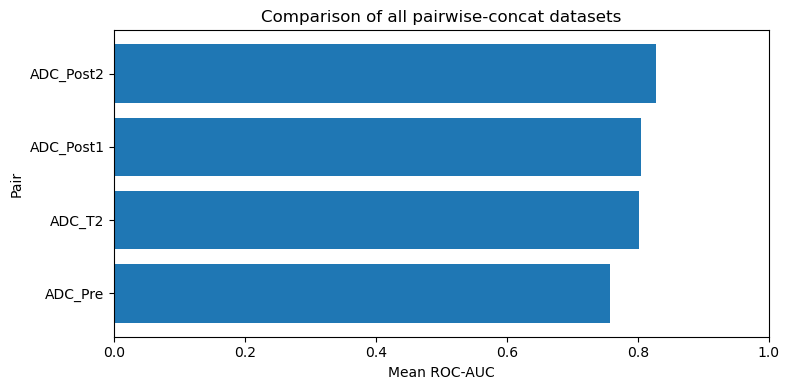

Plot saved:
batch_all_10_pairwise_runner_artifacts_smote_compare/summary_tables/all_10_pairwise_mean_auc_barplot.png


In [ ]:

# =============================================================================
# CELL 8 — PUBLICATION-STYLE COMPACT TABLE AND OPTIONAL PLOT
# =============================================================================

publication_cols = [
    "Pair_Tag",
    "Dataset_A",
    "Dataset_B",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "FS_METHOD",
    "FS_N_FEATURES",
    "USE_SMOTE",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Pooled_Bal_Acc",
    "Mean_F1",
    "Pooled_F1",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Run_Dir",
    "Final_Status",
    "Result_Error",
]

available_publication_cols = [c for c in publication_cols if c in df_all_10_summary.columns]
df_publication_10_pairs = df_all_10_summary[available_publication_cols].copy()

publication_path = SUMMARY_DIR / "publication_all_10_pairwise_concat_summary.csv"
df_publication_10_pairs.to_csv(publication_path, index=False)

print("Publication-style summary saved:")
print(publication_path)

display(df_publication_10_pairs)


# Publication-style SMOTE delta table
if "df_pairwise_smote_vs_no_smote_best" in globals() and len(df_pairwise_smote_vs_no_smote_best) > 0:
    delta_publication_cols = [
        "Pair_Tag",
        "Dataset_A",
        "Dataset_B",
        "Experiment_ID",
        "FS_METHOD",
        "Best_Model_No_SMOTE",
        "Best_Model_SMOTE",
        "Mean_AUC_No_SMOTE",
        "Mean_AUC_SMOTE",
        "Delta_Mean_AUC_SMOTE_minus_No_SMOTE",
        "Pooled_AUC_No_SMOTE",
        "Pooled_AUC_SMOTE",
        "Delta_Pooled_AUC_SMOTE_minus_No_SMOTE",
        "Mean_PR_AUC_No_SMOTE",
        "Mean_PR_AUC_SMOTE",
        "Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE",
        "Mean_Bal_Acc_No_SMOTE",
        "Mean_Bal_Acc_SMOTE",
        "Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE",
        "Avg_Features_No_SMOTE",
        "Avg_Features_SMOTE",
        "Run_Name_No_SMOTE",
        "Run_Name_SMOTE",
    ]
    delta_publication_cols = [
        c for c in delta_publication_cols
        if c in df_pairwise_smote_vs_no_smote_best.columns
    ]
    df_publication_smote_delta = df_pairwise_smote_vs_no_smote_best[delta_publication_cols].copy()

    delta_publication_path = SUMMARY_DIR / "publication_all_10_pairwise_smote_vs_no_smote_summary.csv"
    df_publication_smote_delta.to_csv(delta_publication_path, index=False)

    print("Publication-style SMOTE vs no-SMOTE summary saved:")
    print(delta_publication_path)
    display(df_publication_smote_delta)


# Optional simple plot of Mean_AUC by pair.
try:
    import matplotlib.pyplot as plt

    plot_df = df_publication_10_pairs.copy()
    plot_df["Mean_AUC_numeric"] = pd.to_numeric(plot_df.get("Mean_AUC"), errors="coerce")
    plot_df = plot_df.dropna(subset=["Mean_AUC_numeric"]).sort_values("Mean_AUC_numeric", ascending=True)

    if len(plot_df) > 0:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
        ax.barh(plot_df["Pair_Tag"], plot_df["Mean_AUC_numeric"])
        ax.set_xlabel("Mean ROC-AUC")
        ax.set_ylabel("Pair")
        ax.set_title("Comparison of all pairwise-concat datasets")
        ax.set_xlim(0, 1)
        plt.tight_layout()

        plot_path = SUMMARY_DIR / "all_10_pairwise_mean_auc_barplot.png"
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Plot saved:")
        print(plot_path)

except Exception as e:
    print("Plot skipped:", e)
